In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib

In [9]:
plt.rcParams.update({
    "figure.facecolor":  "#0D0F0E",
    "axes.facecolor":    "#141917",
    "axes.edgecolor":    "#252C29",
    "axes.labelcolor":   "#F0F5F2",
    "xtick.color":       "#6B8076",
    "ytick.color":       "#6B8076",
    "text.color":        "#F0F5F2",
    "grid.color":        "#1C2220",
    "grid.linestyle":    "--",
    "grid.alpha":        0.5,
    "font.family":       "monospace",
})

GREEN = "#00C853"
AMBER = "#FFB300"
RED   = "#FF5252"
DIM   = "#6B8076"

In [10]:
df       = pd.read_csv("../data/creditpulse_data.csv")
pipeline = joblib.load("../models/creditpulse_model.pkl")

FEATURE_COLS = [
    "tx_regularity_score",
    "bill_payment_rate",
    "income_stability",
    "has_savings_behaviour",
    "merchant_diversity",
    "avg_monthly_inflow",
    "account_age_months",
]

LABELS = {
    "tx_regularity_score":   "Transaction Regularity",
    "bill_payment_rate":     "Bill Payment Rate",
    "income_stability":      "Income Stability",
    "has_savings_behaviour": "Savings Behaviour",
    "merchant_diversity":    "Merchant Diversity",
    "avg_monthly_inflow":    "Avg Monthly Inflow",
    "account_age_months":    "Account Age",
}

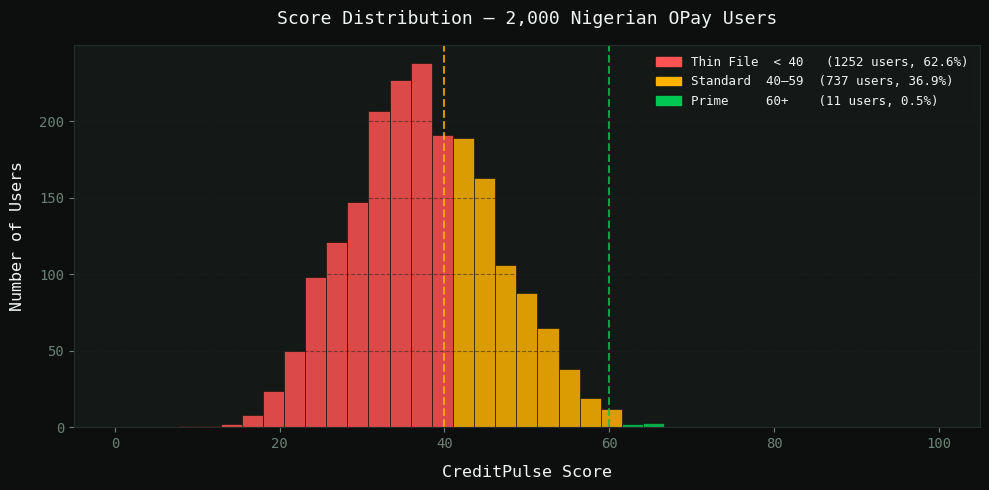

Saved.


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

bins = np.linspace(0, 100, 40)
n, edges, patches = ax.hist(df["credit_score"], bins=bins,
                             edgecolor="#0D0F0E", linewidth=0.5)

for patch, left in zip(patches, edges[:-1]):
    if left < 40:
        patch.set_facecolor(RED)
    elif left < 60:
        patch.set_facecolor(AMBER)
    else:
        patch.set_facecolor(GREEN)
    patch.set_alpha(0.85)

ax.axvline(40, color=AMBER, linewidth=1.5, linestyle="--", alpha=0.8, label="Eligibility threshold (40)")
ax.axvline(60, color=GREEN, linewidth=1.5, linestyle="--", alpha=0.8, label="Prime threshold (60)")

thin  = (df["credit_score"] < 40).sum()
std   = df["credit_score"].between(40, 59.99).sum()
prime = (df["credit_score"] >= 60).sum()

legend_handles = [
    mpatches.Patch(color=RED,   label=f"Thin File  < 40   ({thin} users, {thin/len(df)*100:.1f}%)"),
    mpatches.Patch(color=AMBER, label=f"Standard  40–59  ({std} users, {std/len(df)*100:.1f}%)"),
    mpatches.Patch(color=GREEN, label=f"Prime     60+    ({prime} users, {prime/len(df)*100:.1f}%)"),
]
ax.legend(handles=legend_handles, framealpha=0.15, edgecolor="#252C29", fontsize=9)

ax.set_xlabel("CreditPulse Score", fontsize=12, labelpad=10)
ax.set_ylabel("Number of Users", fontsize=12, labelpad=10)
ax.set_title("Score Distribution — 2,000 Nigerian OPay Users", fontsize=13, pad=15)
ax.grid(axis="y")

plt.tight_layout()
plt.savefig("../data/plot_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

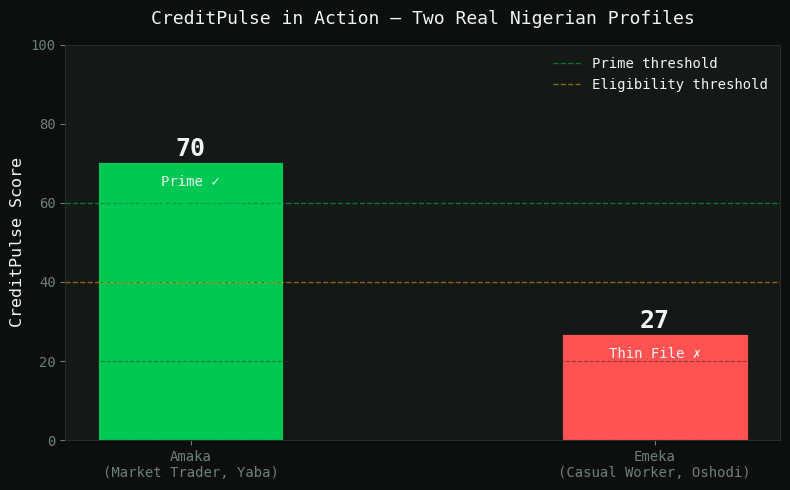

Saved.


In [5]:
model        = pipeline.named_steps["model"]
coefficients = model.coef_
importance   = np.abs(coefficients) / np.abs(coefficients).sum() * 100

feat_df = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": importance,
}).sort_values("importance")

fig, ax = plt.subplots(figsize=(10, 5))

colors = [
    GREEN if v > 18 else AMBER if v > 10 else DIM
    for v in feat_df["importance"]
]

bars = ax.barh(
    [LABELS[f] for f in feat_df["feature"]],
    feat_df["importance"],
    color=colors, edgecolor="#0D0F0E", height=0.55
)

for bar, val in zip(bars, feat_df["importance"]):
    ax.text(
        val + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center", fontsize=10, color="#F0F5F2"
    )

ax.set_xlabel("Contribution to Credit Score (%)", fontsize=12, labelpad=10)
ax.set_title("What Drives the CreditPulse Score", fontsize=13, pad=15)
ax.set_xlim(0, 32)
ax.grid(axis="x")

plt.tight_layout()
plt.savefig("../data/plot_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")